In [15]:
import numpy as np
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')
import matplotlib.pyplot as plt


from impact import Impact

In [16]:
I = Impact('/Users/chrisonian/Downloads/1M_new_settings/ImpactT.in', use_temp_dir=False)
I.verbose=True
I.load_output()

Loaded fort 30 : Fourth root of the fourth moments of the beam distribution
Loaded fort 25 : RMS Y information
Loaded fort 24 : RMS X information
Loaded fort 26 : RMS Z information
Loaded fort 28 : Load balance and loss diagnostics
Loaded fort 29 : Cube root of third moments of the beam distribution
Loaded fort 18 : Time and energy
Loaded fort 27 : Max amplitude information
Loaded fort 70 : Slice information of the final distribution
Loaded fort 60 : Slice information of the initial distribution
Loading particles
Loaded fort 40 : initial particle distribution at t = 0
Loaded fort 50 : final particle distribution projected to the centroid location of the bunch
Converting z to t according to cathode_kinetic_energy_ref = 1.0 eV
Converted initial_particles to ParticleGroup
Converted final_particles to ParticleGroup


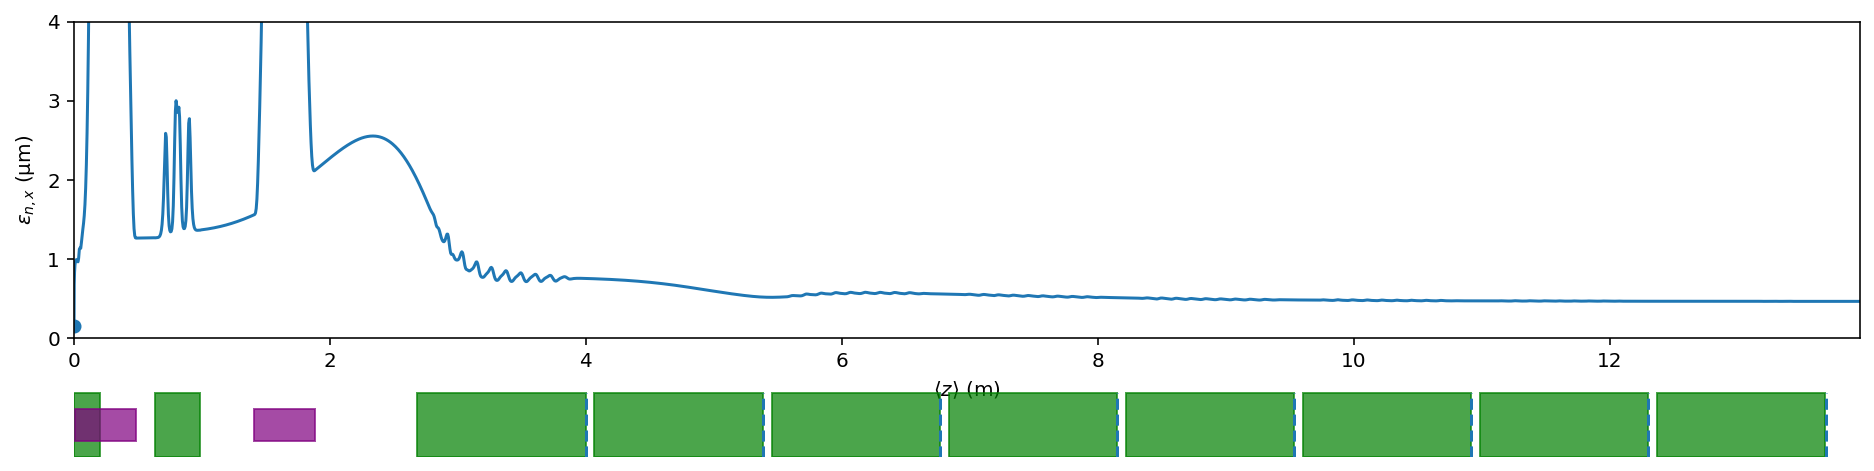

In [17]:
I.plot('norm_emit_x', ylim=(0,4e-6), figsize=(16,4))

In [18]:
from astra import Astra
A = Astra.from_archive('$LCLS_LATTICE/astra/models/sc_inj/v1/astra_sc_inj_v1.h5')

(6e-09, 0.0001)

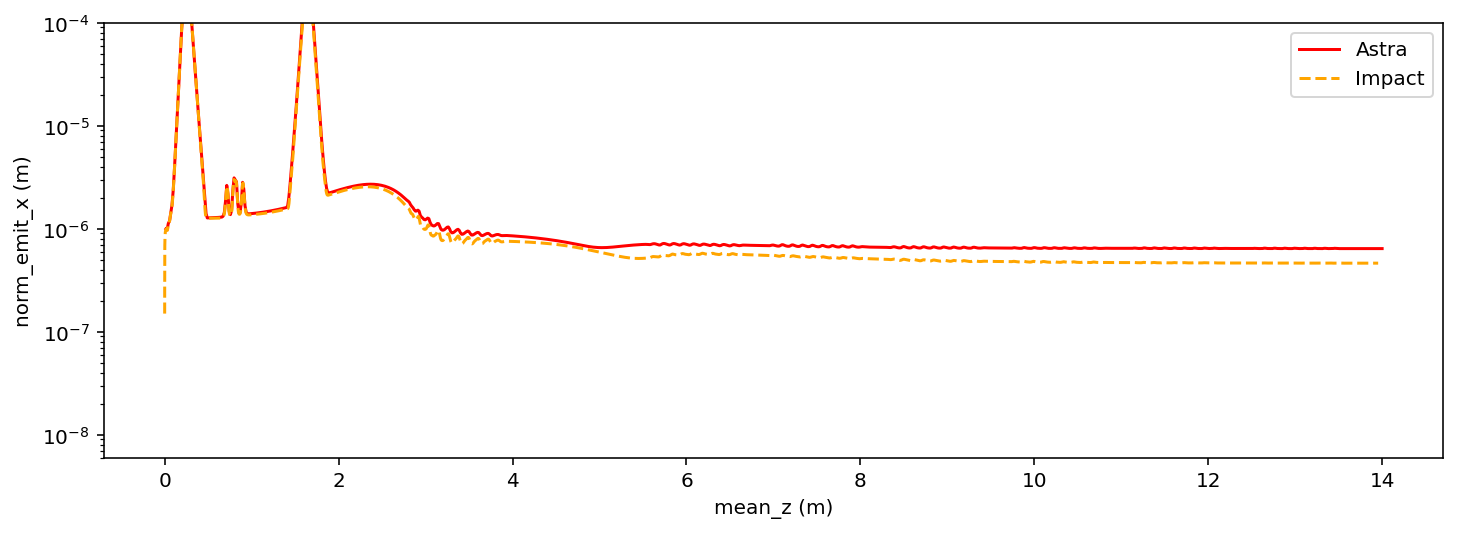

In [19]:
def compare(ykey, xkey = 'mean_z', ylim=None):
    xunits = I.units(xkey)
    yunits = I.units(ykey)
    
    fig, ax = plt.subplots(figsize=(12,4))
    
    ax.plot(A.stat(xkey), A.stat(ykey), label='Astra', color='red')
    ax.plot(I.stat(xkey), I.stat(ykey), '--', label='Impact', color='orange')
    ax.set_xlabel(f'{xkey} ({xunits})')
    ax.set_ylabel(f'{ykey} ({yunits})')
    ax.set_ylim(ylim)
    plt.legend()
    
compare('norm_emit_x', ylim=(0, 3e-6))
plt.yscale('log')
plt.ylim(6e-9, 1e-4)

In [21]:
P0 =I.particles['initial_particles']

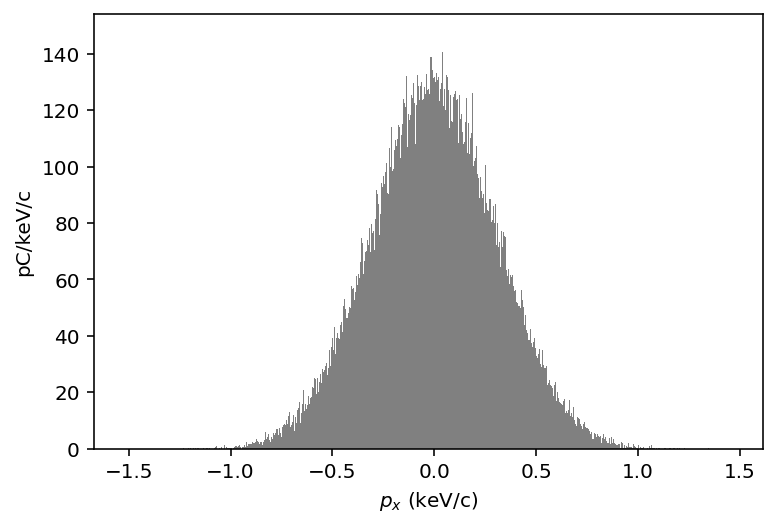

In [29]:
P0.plot('px')

In [90]:
from distgen import Generator
DISTGEN_IN = '$LCLS_LATTICE/distgen/models/sc_inj/v0/distgen.yaml'
G = Generator(DISTGEN_IN)

MTE = 185
G['start:MTE:value'] =MTE
G.run()
P1 = G.particles

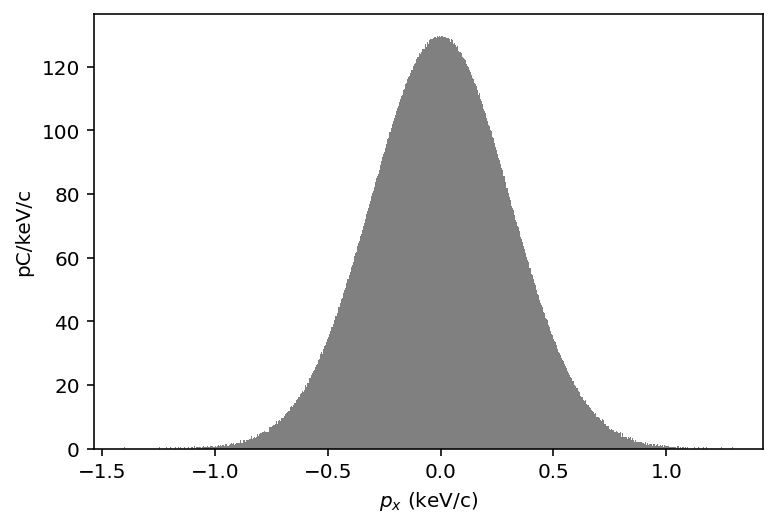

In [72]:
P1.plot('px')

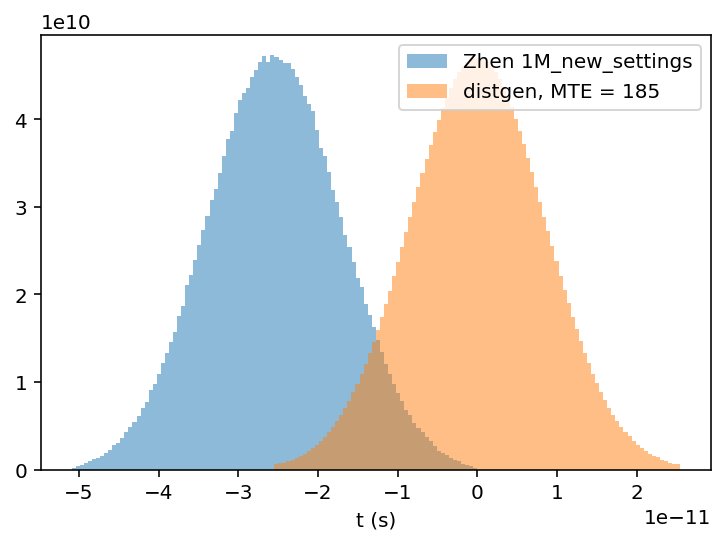

In [93]:
def compare(key):
    plt.hist(P0[key], bins=100, density=True, alpha=0.5, label='Zhen 1M_new_settings');
    plt.hist(P1[key], bins=100, density=True, alpha=0.5, label=f'distgen, MTE = {MTE}');
    plt.xlabel(f'{key} ({P0.units(key)})')
    plt.legend()
compare('t')

In [80]:
str()

'eV/c'

In [95]:
P0['sigma_px'] / 0.511e6

0.000599576190342999